# FFS — testy i klatki syntetyczne

Ten notatnik pracuje **wyłącznie na klatkach syntetycznych** ze znaną prawdą.
Pokazuje, jak testowany jest `pyaraucaria.ffs.FFS`: generator klatek, porównanie
wyników FFS z prawdą i uruchomienie testów. Praca z biblioteką na prawdziwej klatce
z OCA jest w **`ffs_tutorial.ipynb`**.

Konwencje są te same co w tutorialu: `image[y, x]`, `theta` od osi +x przeciwnie do
wskazówek zegara, w [−π/2, π/2); obrazy z `origin="lower"`.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval

# Use the repository version of pyaraucaria and the test helpers in tests/.
# Run this notebook from examples/ inside the repository.
REPO = os.path.abspath("..")
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from pyaraucaria.ffs import FFS
from tests import ffs_synth

warnings.simplefilter("ignore", RuntimeWarning)
%matplotlib inline
# JPEG keeps the notebook small: full-frame noise does not compress as PNG
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}
plt.rcParams["figure.dpi"] = 100


def show(img, ax=None, title=None, extent=None):
    # zscale display, y axis up
    ax = ax or plt.gca()
    norm = ImageNormalize(img, interval=ZScaleInterval())
    ax.imshow(img, origin="lower", cmap="gray", norm=norm, interpolation="nearest",
              extent=extent)
    ax.set_xlabel("x [px]")
    ax.set_ylabel("y [px]")
    if title:
        ax.set_title(title)
    return ax

## 1. Pliki testów

Testy FFS są w trzech plikach w `tests/`:

| plik | co robi |
|---|---|
| `ffs_synth.py` | generator klatek syntetycznych ze znaną prawdą: gwiazdy gaussowskie (eliptyczność, kąt), tło z gradientem, szum Poissona i odczytu, gorące piksele, złe kolumny, ślady satelitów, nasycenie z przelewem. Każdy artefakt jest też zapisywany jako maska `truth["mask_*"]`. Nazwane, deterministyczne scenariusze: `scenario("typical")` itd. |
| `test_ffs_truth.py` | **poprawność**: porównanie wyników FFS z prawdą. Znane błędy są oznaczone `expectedFailure` z opisem `KNOWN BUG`. |
| `test_ffs_regression.py` + `data/ffs_snapshot.json` | **regresja**: wywołania produkcyjne (TOI, Focus, FitsView, filtry `find_stars`, `line_filter`) na wszystkich scenariuszach, porównane z zapisanym stanem. Zamierzoną zmianę zatwierdza się przez `python -m tests.test_ffs_regression --regen`. |

Uruchamianie z katalogu repozytorium:

```bash
python -m unittest tests.test_ffs_truth tests.test_ffs_regression
python -m unittest discover tests        # cały zestaw
```

## 2. Klatka syntetyczna i jej prawda

42 gwiazd, gorące piksele: 3, zła kolumna: 512 px, ślad: 3604 px, nasycone: 72 px


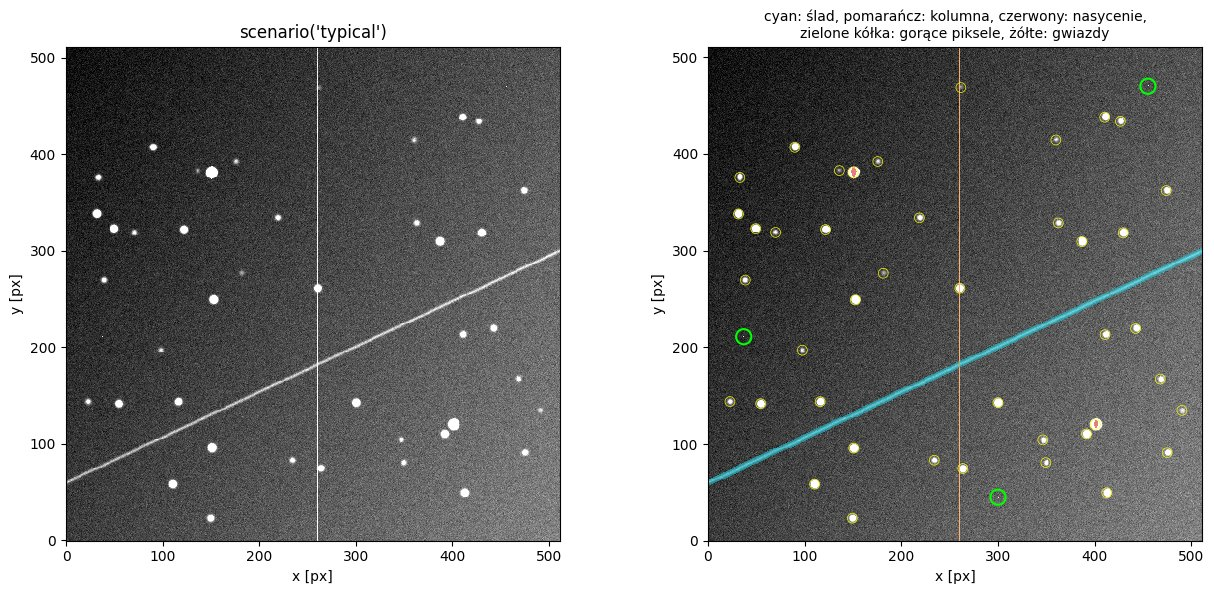

In [2]:
syn = ffs_synth.scenario("typical")
truth = syn.truth
print(f"{len(syn.stars)} gwiazd, gorące piksele: {truth['mask_hot'].sum()}, "
      f"zła kolumna: {truth['mask_bad_column'].sum()} px, ślad: {truth['mask_line'].sum()} px, "
      f"nasycone: {truth['mask_saturated'].sum()} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
show(syn.image, axes[0], "scenario('typical')")
show(syn.image, axes[1], "prawda: wstrzyknięte artefakty")
for name, color in [("mask_line", "tab:cyan"), ("mask_bad_column", "tab:orange"),
                    ("mask_saturated", "tab:red")]:
    overlay = np.ma.masked_where(~truth[name], np.ones_like(syn.image))
    axes[1].imshow(overlay, origin="lower", cmap=plt.matplotlib.colors.ListedColormap([color]),
                   alpha=0.6, interpolation="nearest")
hy, hx = np.nonzero(truth["mask_hot"])
axes[1].scatter(hx, hy, s=120, facecolors="none", edgecolors="lime", lw=1.5)
axes[1].scatter([s["x"] for s in syn.stars], [s["y"] for s in syn.stars], s=50,
                facecolors="none", edgecolors="yellow", lw=0.5)
axes[1].set_xlim(0, 511); axes[1].set_ylim(0, 511)
axes[1].set_title("cyan: ślad, pomarańcz: kolumna, czerwony: nasycenie,\n"
                  "zielone kółka: gorące piksele, żółte: gwiazdy", fontsize=10)
plt.tight_layout()

## 3. Gorące piksele a filtry `find_stars()`

Bez filtrów gorące piksele są wykrywane jako „gwiazdy” (zachowanie zgodne z historią,
utrwalone w teście). `max_concentration=0.5` i `min_pixels_above_threshold=5` je odrzucają.

In [3]:
hot_xy = np.argwhere(truth["mask_hot"])[:, ::-1]


def detected_hot(ffs_obj):
    xy = np.column_stack([ffs_obj.coo[:, 1], ffs_obj.coo[:, 0]])
    return sum(np.min(np.hypot(*(xy - h).T)) <= 1 for h in hot_xy)


plain = FFS(syn.image); plain.mk_stats(); plain.find_stars(threshold=5, fwhm=4)
filt = FFS(syn.image); filt.mk_stats()
filt.find_stars(threshold=5, fwhm=4, max_concentration=0.5, min_pixels_above_threshold=5)
print(f"bez filtrów: {len(plain.coo):3d} źródeł, w tym gorących pikseli: {detected_hot(plain)} / {len(hot_xy)}")
print(f"z filtrami:  {len(filt.coo):3d} źródeł, w tym gorących pikseli: {detected_hot(filt)} / {len(hot_xy)}")

bez filtrów: 156 źródeł, w tym gorących pikseli: 3 / 3
z filtrami:  124 źródeł, w tym gorących pikseli: 0 / 3


## 4. Kształt gwiazd: FFS a prawda

Scenariusz `elliptical`: wszystkie gwiazdy mają FWHM osi głównej 5 px, eliptyczność 0,3
i `theta` = 30°. Przed poprawkami FFS dawał tu eliptyczność 0,07 (szum w pudełku),
kąt mierzony od niewłaściwej osi i `theta_spread` ≈ 1 rad.

frame_ellipticity  = 0.301   (prawda 0.300)
theta (mediana)    = 30.0°  (prawda 30.0°)
frame_theta_spread = 0.66°


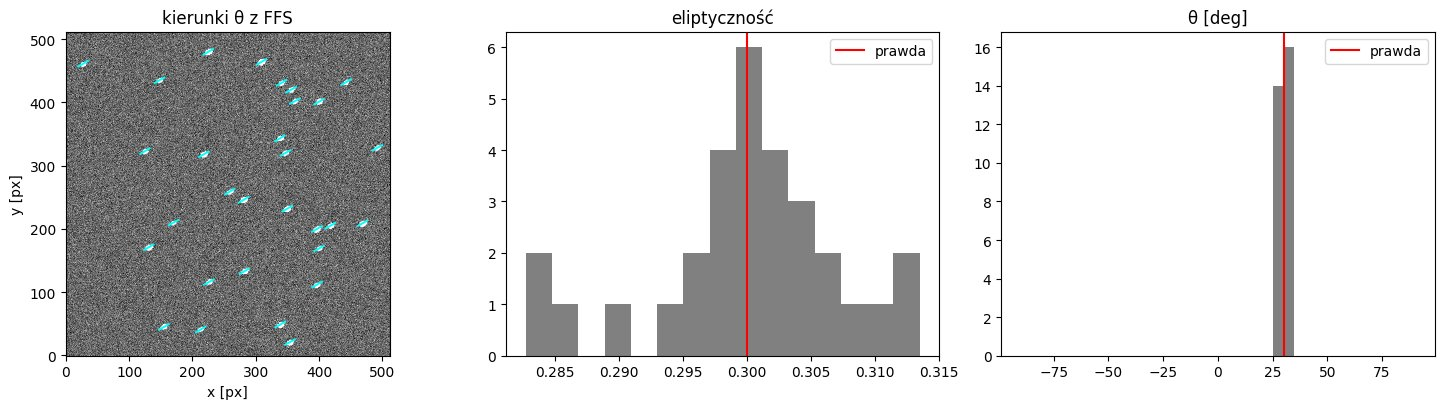

In [4]:
ell = ffs_synth.scenario("elliptical")
fe = FFS(ell.image)
fe.calc_frame_fwhm(threshold=10, fwhm=5, box=15, N_stars=50, clip=4)

print(f"frame_ellipticity  = {fe.frame_ellipticity:.3f}   (prawda 0.300)")
print(f"theta (mediana)    = {np.rad2deg(np.median(fe.theta)):.1f}°  (prawda 30.0°)")
print(f"frame_theta_spread = {np.rad2deg(fe.frame_theta_spread):.2f}°")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
show(ell.image, axes[0], "scenario('elliptical')")
st = fe.stars
axes[0].quiver(st["x"], st["y"], np.cos(st["theta"]), np.sin(st["theta"]), color="cyan",
               angles="xy", headwidth=0, headlength=0, headaxislength=0, pivot="middle",
               scale=25, width=0.006)
axes[0].set_title("kierunki θ z FFS")
axes[1].hist(st["ellipticity"], bins=15, color="0.5"); axes[1].axvline(0.3, color="r", label="prawda")
axes[1].set_title("eliptyczność"); axes[1].legend()
axes[2].hist(np.rad2deg(st["theta"]), bins=36, range=(-90, 90), color="0.5")
axes[2].axvline(30, color="r", label="prawda"); axes[2].set_title("θ [deg]"); axes[2].legend()
plt.tight_layout()

## 5. Linie: wstrzyknięty ślad satelity

`find_lines()` (transformata Hougha na `ffs.maska`) na klatce z jednym wstrzykniętym
śladem satelity, od (0, 60) do (511, 300). Najsilniejsza linia trafia w ślad. Pozostałe
(pomarańczowe) to znane ograniczenie: jeden ślad raportowany jako kilka linii
(test `test_single_trail_single_line`, `expectedFailure`).

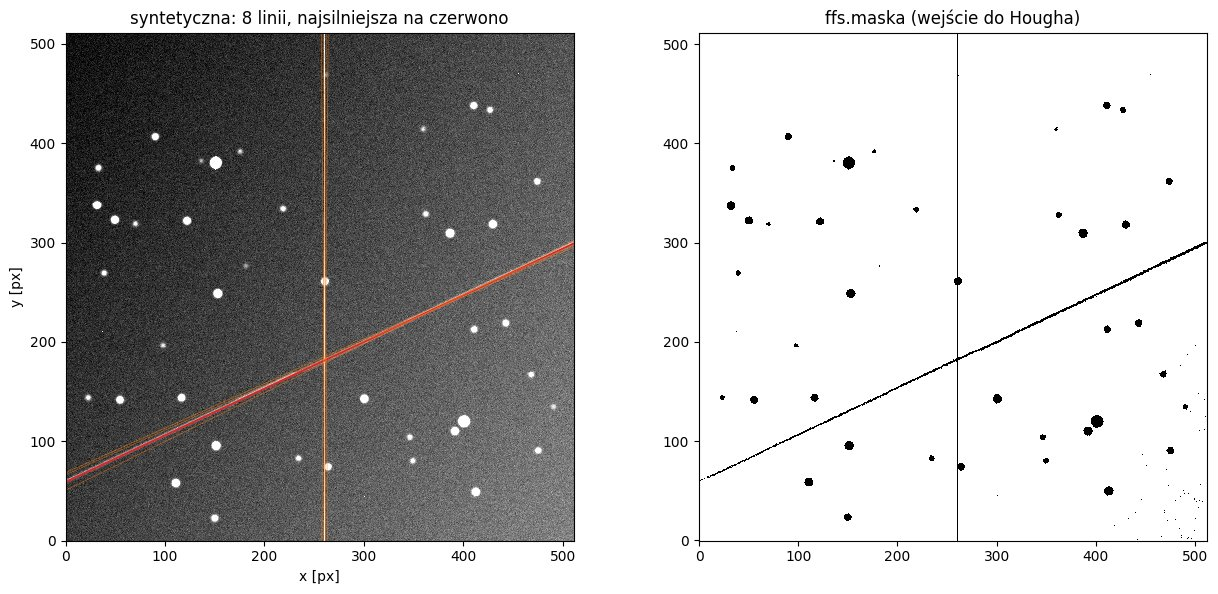

In [5]:
def line_xy(rho, theta, length):
    c, s = np.cos(theta), np.sin(theta)
    x0, y0 = rho * c, rho * s
    return np.array([x0 - length * s, x0 + length * s]), np.array([y0 + length * c, y0 - length * c])


syn = ffs_synth.scenario("typical")
fs = FFS(syn.image); fs.mk_stats(); fs.find_lines()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
show(syn.image, axes[0], f"syntetyczna: {len(fs.lines_val)} linii, najsilniejsza na czerwono")
for i, (r, t) in enumerate(zip(fs.lines_rho, fs.lines_theta)):
    xs, ys = line_xy(r, t, 2000)
    axes[0].plot(xs, ys, color="tab:red" if i == 0 else "tab:orange", lw=1.5 if i == 0 else 0.5,
                 alpha=1 if i == 0 else 0.6)
axes[0].set_xlim(0, 511); axes[0].set_ylim(0, 511)
axes[1].imshow(fs.maska, origin="lower", cmap="gray_r", interpolation="nearest")
axes[1].set_title("ffs.maska (wejście do Hougha)")
plt.tight_layout()

## 6. Uruchomienie testów

`expected failure` oznacza znany, udokumentowany błąd, który jeszcze nie jest naprawiony
(obecnie tylko Hough). Gdy po poprawce taki test zacznie przechodzić, unittest zgłosi
`unexpected success` — wtedy należy zdjąć dekorator.

In [6]:
import unittest

suite = unittest.TestSuite(
    unittest.defaultTestLoader.loadTestsFromName(name)
    for name in ["tests.test_ffs_truth", "tests.test_ffs_regression"]
)
result = unittest.TextTestRunner(verbosity=2, stream=sys.stdout).run(suite)
print()
print(f"testów: {result.testsRun}, błędy: {len(result.errors)}, porażki: {len(result.failures)}, "
      f"oczekiwane porażki: {len(result.expectedFailures)}, nieoczekiwane sukcesy: {len(result.unexpectedSuccesses)}")

test_clean_field_complete_and_pure (tests.test_ffs_truth.TestFindStars.test_clean_field_complete_and_pure) ... 

ok


test_empty_field_no_detections (tests.test_ffs_truth.TestFindStars.test_empty_field_no_detections) ... 

ok


test_hot_pixels_detected_without_filters (tests.test_ffs_truth.TestFindStars.test_hot_pixels_detected_without_filters) ... 

...

ok


test_toi (tests.test_ffs_regression.TestFFSRegression.test_toi) ... 

ok


----------------------------------------------------------------------
Ran 38 tests in 6.626s

OK (expected failures=2)



testów: 38, błędy: 0, porażki: 0, oczekiwane porażki: 2, nieoczekiwane sukcesy: 0
